In [64]:
# Ignore all warning messages during code execution
import warnings
warnings.filterwarnings('ignore')

In [65]:
# Set the number of threads to 1 to avoid memory leak warnings on Windows
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [66]:
# Import pandas for data manipulation and matplotlib for data visualization
import pandas as pd 
import matplotlib.pyplot as plt

In [67]:
# Import KMeans for clustering, StandardScaler for feature scaling, and PCA for dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [68]:
# Load the Mall Customers dataset from a local CSV file into a pandas DataFrame
df = pd.read_csv(r"C:\Users\HP 9480\OneDrive\Desktop\Sami folder\Mall_Customers.csv")

In [69]:
# Select features (Annual Income and Spending Score) for clustering analysis
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [70]:
# Standardize the features to have a mean of 0 and a Standard deviation of 1 before clustering
scaler = StandardScaler()
X_scaled =  scaler.fit_transform(X)

In [71]:
# Compute WCSS values for different numbers of clusters (1 to 10) using KMeans to help determine the optimal number of clusters.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

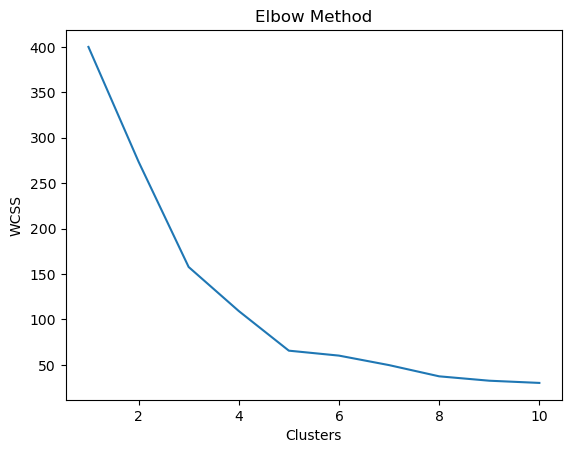

In [72]:
# Plot the Elbow Method graph to visualize WCSS and determine the optimal number of clusters
plt.plot(range(1, 11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [73]:
# Initialize the KMeans model with 5 clusters and a fixed random state for reproducibility
kmeans = KMeans(n_clusters=5, random_state=42)

In [74]:
# Fit the KMeans model on scaled data and assign each data point to a cluster
clusters = kmeans.fit_predict(X_scaled)

In [75]:
# Add the cluster labels as a new column in the DataFrame
df['Cluster'] = clusters

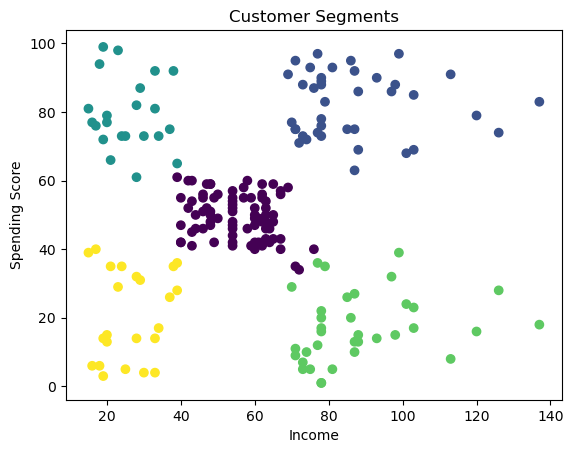

In [76]:
# Visualize customer segments using a scatter plot colored by cluster assignments
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

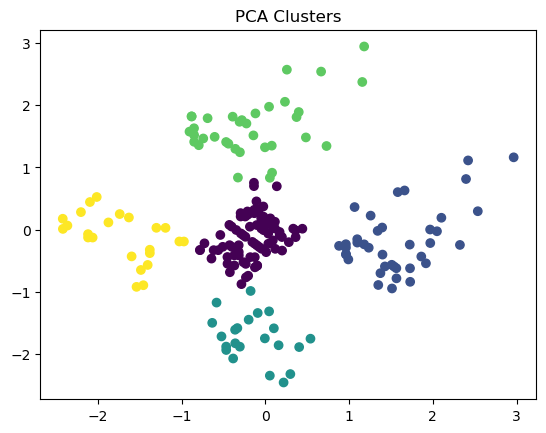

In [79]:
# Reduce data to 2 principal components using PCA and visualize the KMeans clusters in 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("PCA Clusters")
plt.show()

In [80]:
# Display the first 5 rows of the DataFrame to inspect the data and cluster assignments
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
